In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"C:\Users\admin\Downloads\Data Set For Task-20260821T102726Z-1-001\Data Set For Task\2) Stock Prices Data Set.csv")

In [8]:
df.head(10)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
5,ABT,2014-01-02,38.0900,38.4000,38.0000,38.2300,4967472
6,ACN,2014-01-02,81.5000,81.9200,81.0900,81.1300,2405384
7,ADBE,2014-01-02,59.0600,59.5300,58.9400,59.2900,2746370
8,ADI,2014-01-02,49.5200,49.7500,49.0400,49.2800,2799092
9,ADM,2014-01-02,43.2200,43.2900,42.7900,42.9900,2753765


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 32.8 MB


In [11]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [15]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
df["date"] = pd.to_datetime(df["date"])

In [18]:
df = df.sort_values(["symbol", "date"])

In [19]:
df[["open", "high", "low"]] = (df.groupby("symbol")[["open", "high", "low"]].ffill())

In [20]:
df.isnull().sum()

symbol    0
date      0
open      2
high      2
low       2
close     0
volume    0
dtype: int64

In [22]:
df.head(10)

,symbol,date,open,high,low,close,volume
57,A,2014-01-02,57.10,57.100,56.150,56.21,1916160
540,A,2014-01-03,56.39,57.345,56.260,56.92,1866651
1023,A,2014-01-06,57.40,57.700,56.560,56.64,1777472
1506,A,2014-01-07,56.95,57.630,56.930,57.45,1463208
1989,A,2014-01-08,57.33,58.540,57.170,58.39,2659468
2472,A,2014-01-09,58.40,58.680,57.870,58.41,1757647
2955,A,2014-01-10,58.51,59.010,58.140,58.93,1623330
3438,A,2014-01-13,58.77,59.100,58.600,58.93,2946738
3921,A,2014-01-14,59.16,59.950,59.020,59.88,2562236
4404,A,2014-01-15,59.82,60.365,59.585,60.34,2335194


In [27]:
numeric_cols = ["open","high","low","close","volume"]
print("Mean:")
print(df[numeric_cols].mean())

print("\nMedian:")
print(df[numeric_cols].median())

print("\nMode:")
print(df[numeric_cols].mode())

print("\nStandard Deviation:")
print(df[numeric_cols].std())

Mean:
open      8.635297e+01
high      8.713342e+01
low       8.555328e+01
close     8.636908e+01
volume    4.253611e+06
dtype: float64

Median:
open      6.497000e+01
high      6.556000e+01
low       6.435870e+01
close     6.498000e+01
volume    2.084896e+06
dtype: float64

Mode:
   open  high   low  close   volume
0  70.0  72.0  77.0   34.5  1241019

Standard Deviation:
open      1.014724e+02
high      1.023135e+02
low       1.005723e+02
close     1.014724e+02
volume    8.232139e+06
dtype: float64


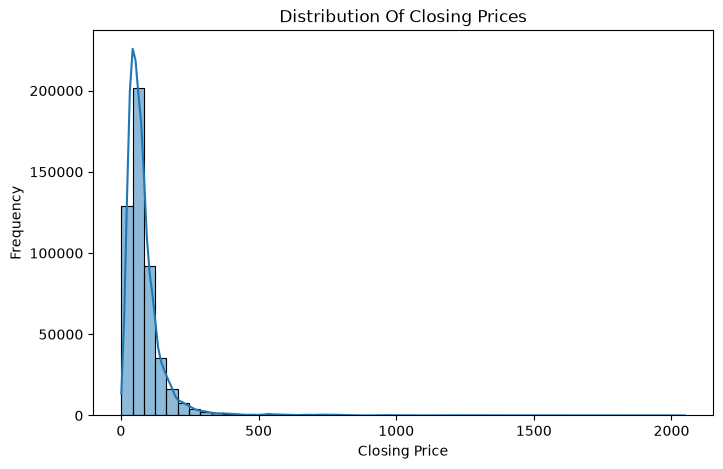

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["close"], bins = 50, kde = True)
plt.title("Distribution Of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

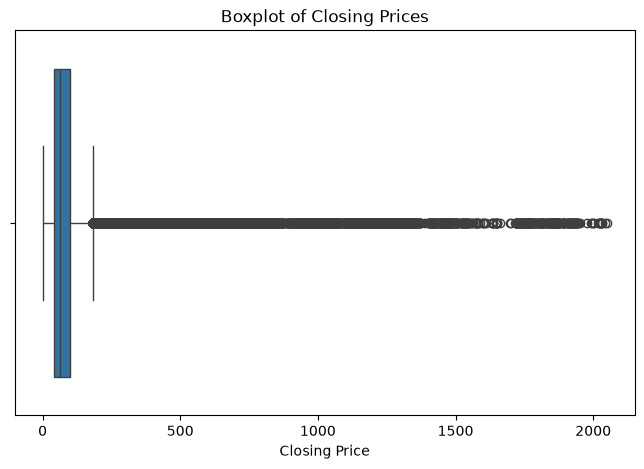

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["close"])
plt.title("Boxplot of Closing Prices")
plt.xlabel("Closing Price")
plt.show()

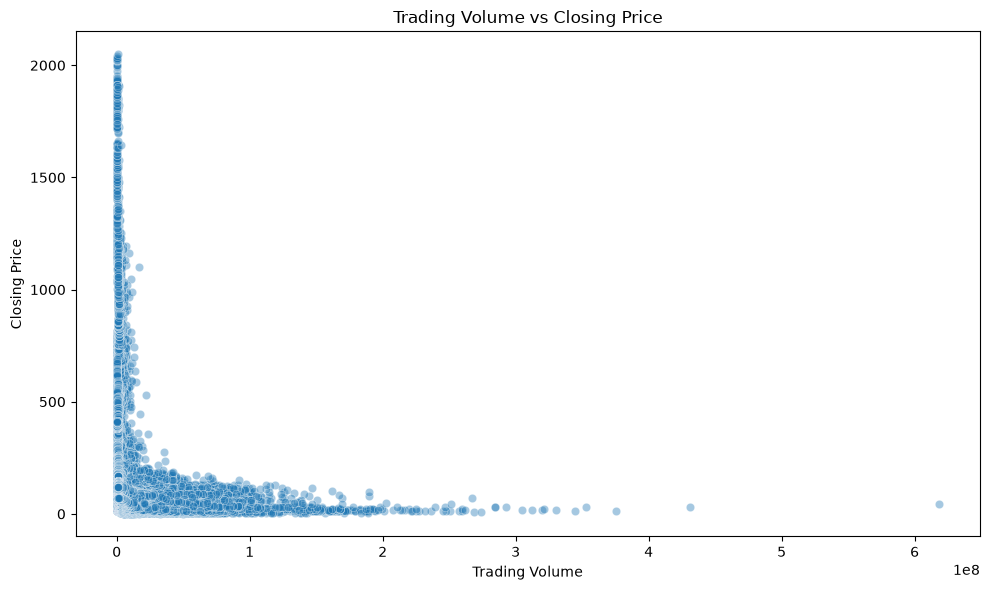

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="volume",
    y="close",
    alpha=0.4
)
plt.title("Trading Volume vs Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.show()

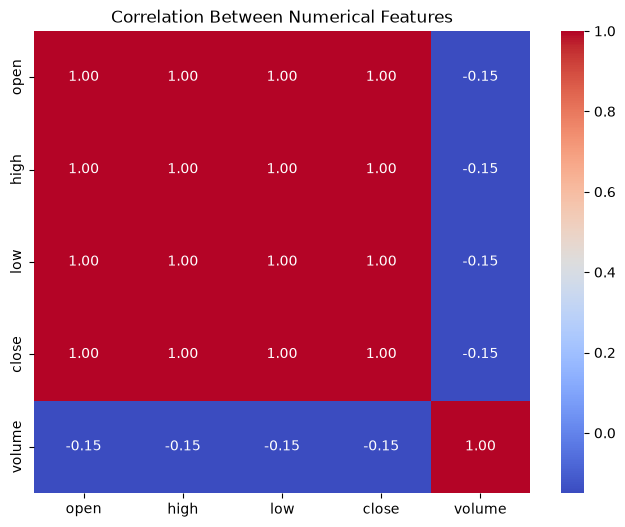

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Numerical Features")
plt.show()